# ВКР: Предсказание популярности музыкального трека
## Level 5: Мультимодальная Fusion-модель

**Вход:** `dataset_clean.csv`, `audio_features.csv`, `text_features.csv`, `lastfm_cache.csv`

**Модальности:**
- L1: Spotify features (14)
- L2a: Internal context — target encoding (6)
- L2b: External context — Last.fm listeners/playcount (2)
- L3a: Librosa handcrafted (~105)
- L3b: VGGish learned-classification (128)
- L3c: CLAP learned-contrastive (512)
- L4: Text — SBERT + VADER + метрики (397)

**Выход:** `level5_results.csv`, сохранённые модели

---
## 1. Импорт и загрузка

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os, re, json, joblib, time
from tqdm import tqdm
import warnings; warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, StackingRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    roc_auc_score, accuracy_score, f1_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)

plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 12
sns.set_style('whitegrid')
print('OK')

OK


In [2]:
# Загрузка данных
df = pd.read_csv('dataset_clean.csv')
df['explicit'] = df['explicit'].astype(int)
target = 'popularity'

df_audio = pd.read_csv('audio_features.csv')
df_text = pd.read_csv('text_features.csv')

print(f'Датасет: {len(df):,}')
print(f'Audio: {len(df_audio):,} треков, {len(df_audio.columns)} колонок')
print(f'Text: {len(df_text):,} треков, {len(df_text.columns)} колонок')

Датасет: 81,207
Audio: 78,586 треков, 1258 колонок
Text: 68,176 треков, 398 колонок


In [3]:
# Определяем группы признаков
spotify_features = ['danceability','energy','loudness','speechiness','acousticness',
    'instrumentalness','liveness','valence','tempo','duration_ms','key','mode','time_signature','explicit']

librosa_names = [c for c in df_audio.columns if c not in ['_idx'] and not c.startswith('vggish_') and not c.startswith('clap_')]
vggish_names = [c for c in df_audio.columns if c.startswith('vggish_')]
clap_names = [c for c in df_audio.columns if c.startswith('clap_')]
sbert_cols = [c for c in df_text.columns if c.startswith('sbert_')]
metrics_cols = [c for c in df_text.columns if c not in sbert_cols and c != '_idx']
text_names = metrics_cols + sbert_cols

print(f'Spotify: {len(spotify_features)}, Librosa: {len(librosa_names)}, VGGish: {len(vggish_names)}, CLAP: {len(clap_names)}')
print(f'Text: {len(text_names)} (metrics: {len(metrics_cols)}, SBERT: {len(sbert_cols)})')

Spotify: 14, Librosa: 105, VGGish: 128, CLAP: 1024
Text: 397 (metrics: 13, SBERT: 384)


In [4]:
# Internal context (target encoding)
df_nonzero = df[df[target] > 0]
genre_mean = df_nonzero.groupby('track_genre')[target].mean()
df['genre_mean_popularity'] = df['track_genre'].map(genre_mean).fillna(0)

artist_agg = df_nonzero.groupby('artists')[target].agg(
    artist_mean_popularity='mean', artist_median_popularity='median',
    artist_max_popularity='max', artist_std_popularity='std', artist_track_count='count'
).fillna(0)
for col in artist_agg.columns:
    df[col] = df['artists'].map(artist_agg[col]).fillna(0)

internal_features = ['artist_mean_popularity','artist_median_popularity','artist_max_popularity',
                     'artist_std_popularity','artist_track_count','genre_mean_popularity']

# External context (Last.fm)
if os.path.exists('lastfm_cache.csv'):
    df_lastfm = pd.read_csv('lastfm_cache.csv')
    lastfm_dict = {row['artist']: row for _, row in df_lastfm.iterrows()}
    def first_artist(name):
        if not isinstance(name, str): return ''
        return re.split(r'[,;&]|\sfeat\.?\s|\sft\.?\s', name, flags=re.IGNORECASE)[0].strip()
    df['_fa'] = df['artists'].apply(first_artist)
    df['lastfm_listeners'] = df['_fa'].map({k: v.get('lastfm_listeners',0) for k,v in lastfm_dict.items()}).fillna(0)
    df['lastfm_playcount'] = df['_fa'].map({k: v.get('lastfm_playcount',0) for k,v in lastfm_dict.items()}).fillna(0)
    df['lastfm_listeners_log'] = np.log1p(df['lastfm_listeners'])
    df['lastfm_playcount_log'] = np.log1p(df['lastfm_playcount'])
    df = df.drop(columns=['_fa'])
    external_features = ['lastfm_listeners_log','lastfm_playcount_log']
    print(f'Last.fm: {(df["lastfm_listeners"]>0).sum():,} треков с данными')
else:
    external_features = []
    print('Last.fm кеш не найден')

context_features = internal_features + external_features
print(f'Context: {len(context_features)} (internal: {len(internal_features)}, external: {len(external_features)})')

Last.fm: 81,191 треков с данными
Context: 8 (internal: 6, external: 2)


In [5]:
# Fusion: пересечение аудио и текста
audio_idx = set(df_audio['_idx'].astype(int).tolist())
text_idx = set(df_text['_idx'].astype(int).tolist())
fusion_idx = sorted(audio_idx & text_idx)

print(f'Audio: {len(audio_idx):,}, Text: {len(text_idx):,}, Пересечение: {len(fusion_idx):,}')

Audio: 78,586, Text: 68,176, Пересечение: 66,311


In [6]:
# Собираем fusion датасет
df_fusion = df.iloc[fusion_idx][spotify_features + context_features + [target]].copy().reset_index(drop=True)

# Аудио
audio_map = df_audio.set_index('_idx')
for f in librosa_names + vggish_names + clap_names:
    df_fusion[f] = [audio_map.loc[i, f] if i in audio_map.index else 0 for i in fusion_idx]

# Текст
text_map = df_text.set_index('_idx')
for f in text_names:
    df_fusion[f] = [text_map.loc[i, f] if i in text_map.index else 0 for i in fusion_idx]

print(f'\nFusion датасет: {len(df_fusion):,} треков, {len(df_fusion.columns)} колонок')
print(f'Popularity: min={df_fusion[target].min()}, max={df_fusion[target].max()}, mean={df_fusion[target].mean():.1f}')


Fusion датасет: 66,311 треков, 1677 колонок
Popularity: min=3, max=100, mean=40.1


---
## 2. Ablation Study

In [7]:
y = df_fusion[target]
tr, te = train_test_split(np.arange(len(df_fusion)), test_size=0.2, random_state=42)
threshold = y.iloc[tr].median()
y_te_bin = (y.iloc[te] >= threshold).astype(int)
print(f'Train: {len(tr):,}, Test: {len(te):,}, Порог: {threshold}')

configs = {
    'L1: Spotify':           spotify_features,
    'L2a: Internal':         internal_features,
    'L2b: External':         external_features,
    'L3a: Librosa':          librosa_names,
    'L3b: VGGish':           vggish_names,
    'L3c: CLAP':             clap_names,
    'L4: Text':              text_names,
    'L1+L2a+L2b':            spotify_features + context_features,
    'L1+L3a':                spotify_features + librosa_names,
    'L1+L3b':                spotify_features + vggish_names,
    'L1+L3c':                spotify_features + clap_names,
    'L1+L4':                 spotify_features + text_names,
    'L1+L3a+L4':             spotify_features + librosa_names + text_names,
    'L1+L3b+L4':             spotify_features + vggish_names + text_names,
    'L1+L3c+L4':             spotify_features + clap_names + text_names,
    'Content (all-context)':  spotify_features + librosa_names + vggish_names + clap_names + text_names,
    'FULL (all)':            spotify_features + context_features + librosa_names + vggish_names + clap_names + text_names,
}

model_types = {
    'Linear Regression': lambda: LinearRegression(),
    'Random Forest': lambda: RandomForestRegressor(n_estimators=300, max_depth=15, min_samples_split=10, min_samples_leaf=5, random_state=42, n_jobs=-1),
    'XGBoost': lambda: XGBRegressor(n_estimators=300, max_depth=6, learning_rate=0.1, subsample=0.8, colsample_bytree=0.8, random_state=42, n_jobs=-1, verbosity=0),
    'LightGBM': lambda: LGBMRegressor(n_estimators=300, max_depth=10, learning_rate=0.1, subsample=0.8, colsample_bytree=0.8, random_state=42, n_jobs=-1, verbose=-1),
}

print(f'{len(configs)} конфигураций × {len(model_types)} моделей = {len(configs)*len(model_types)} экспериментов')

Train: 53,048, Test: 13,263, Порог: 40.0
17 конфигураций × 4 моделей = 68 экспериментов


In [8]:
results = {}
print(f'{"Config":28s} | {"Model":20s} | {"MAE":>7s} | {"RMSE":>7s} | {"R²":>7s} | {"AUC":>7s}')
print('='*105)
for cname, flist in configs.items():
    if not flist: continue
    Xtr, Xte = df_fusion[flist].iloc[tr], df_fusion[flist].iloc[te]
    sc = StandardScaler(); Xtr_s, Xte_s = sc.fit_transform(Xtr), sc.transform(Xte)
    for mname, mfn in model_types.items():
        m = mfn(); m.fit(Xtr_s, y.iloc[tr]); yp = m.predict(Xte_s)
        mae=mean_absolute_error(y.iloc[te],yp); rmse=np.sqrt(mean_squared_error(y.iloc[te],yp))
        r2=r2_score(y.iloc[te],yp); auc=roc_auc_score(y_te_bin,yp)
        results[(cname,mname)]={'MAE':mae,'RMSE':rmse,'R2':r2,'AUC':auc,'model':m,'scaler':sc,'y_pred':yp}
        print(f'{cname:28s} | {mname:20s} | {mae:7.3f} | {rmse:7.3f} | {r2:7.4f} | {auc:7.4f}')
    print('-'*105)

Config                       | Model                |     MAE |    RMSE |      R² |     AUC
L1: Spotify                  | Linear Regression    |  13.163 |  15.899 |  0.0837 |  0.6319
L1: Spotify                  | Random Forest        |  12.139 |  14.909 |  0.1943 |  0.7099
L1: Spotify                  | XGBoost              |  12.043 |  14.881 |  0.1972 |  0.7123
L1: Spotify                  | LightGBM             |  12.099 |  14.899 |  0.1954 |  0.7094
---------------------------------------------------------------------------------------------------------
L2a: Internal                | Linear Regression    |   3.583 |   6.161 |  0.8624 |  0.9687
L2a: Internal                | Random Forest        |   3.458 |   6.343 |  0.8541 |  0.9666
L2a: Internal                | XGBoost              |   3.432 |   6.332 |  0.8547 |  0.9668
L2a: Internal                | LightGBM             |   3.378 |   6.213 |  0.8601 |  0.9682
------------------------------------------------------------------

In [9]:
# Лучшая модель
cnames = list(configs.keys()); mnames = list(model_types.keys())
best = max(mnames, key=lambda m: np.mean([results[(c,m)]['R2'] for c in cnames if (c,m) in results]))
print(f'Лучшая модель (по ср. R²): {best}\n')
for c in cnames:
    if (c,best) not in results: continue
    r = results[(c,best)]
    print(f'  {c:28s}  R²={r["R2"]:7.4f}  MAE={r["MAE"]:7.3f}  RMSE={r["RMSE"]:7.4f}  AUC={r["AUC"]:7.4f}  [{len(configs[c])} фичей]')

Лучшая модель (по ср. R²): LightGBM

  L1: Spotify                   R²= 0.1954  MAE= 12.099  RMSE=14.8988  AUC= 0.7094  [14 фичей]
  L2a: Internal                 R²= 0.8601  MAE=  3.378  RMSE= 6.2133  AUC= 0.9682  [6 фичей]
  L2b: External                 R²= 0.4129  MAE= 10.127  RMSE=12.7260  AUC= 0.8144  [2 фичей]
  L3a: Librosa                  R²= 0.1873  MAE= 12.053  RMSE=14.9731  AUC= 0.7194  [105 фичей]
  L3b: VGGish                   R²= 0.2495  MAE= 11.376  RMSE=14.3892  AUC= 0.7539  [128 фичей]
  L3c: CLAP                     R²= 0.2421  MAE= 11.468  RMSE=14.4597  AUC= 0.7467  [1024 фичей]
  L4: Text                      R²= 0.2800  MAE= 11.115  RMSE=14.0931  AUC= 0.7714  [397 фичей]
  L1+L2a+L2b                    R²= 0.8726  MAE=  3.313  RMSE= 5.9274  AUC= 0.9716  [22 фичей]
  L1+L3a                        R²= 0.2990  MAE= 11.148  RMSE=13.9064  AUC= 0.7688  [119 фичей]
  L1+L3b                        R²= 0.3466  MAE= 10.633  RMSE=13.4259  AUC= 0.7901  [142 фичей]
  L1+L3c

---
## 3. Handcrafted vs Learned (3-way)

=== Handcrafted vs Learned (3-way) ===
Model                    Librosa      VGGish        CLAP     VGG-Lib    CLAP-Lib
Linear Regression         0.1068      0.1866      0.2277     +0.0798     +0.1209
Random Forest             0.1711      0.2517      0.2330     +0.0806     +0.0619
XGBoost                   0.1827      0.2528      0.2438     +0.0700     +0.0611
LightGBM                  0.1873      0.2495      0.2421     +0.0622     +0.0548


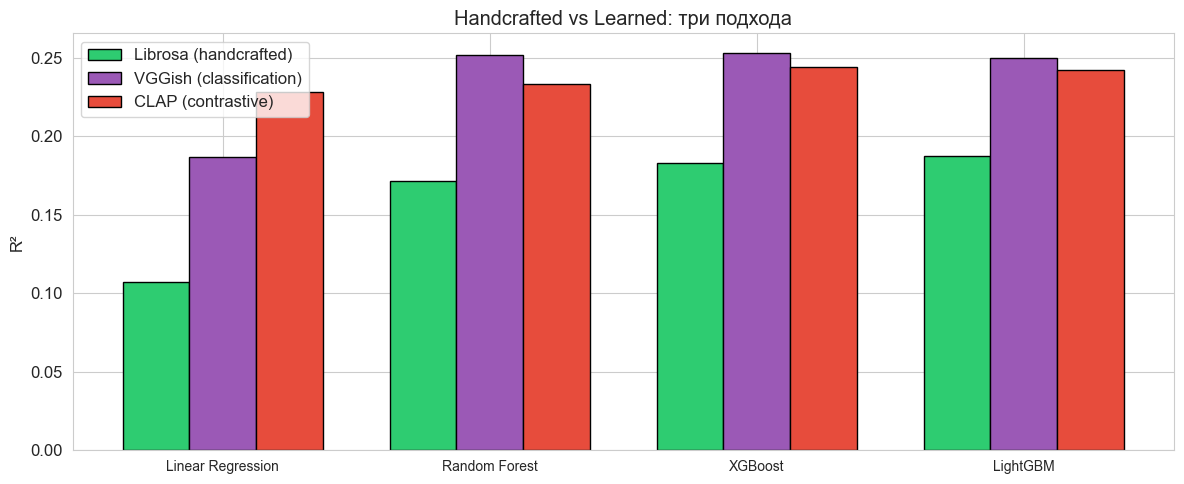

In [10]:
print('=== Handcrafted vs Learned (3-way) ===')
print(f'{"Model":20s}  {"Librosa":>10s}  {"VGGish":>10s}  {"CLAP":>10s}  {"VGG-Lib":>10s}  {"CLAP-Lib":>10s}')
for m in mnames:
    rl=results[('L3a: Librosa',m)]['R2']; rv=results[('L3b: VGGish',m)]['R2']; rc=results[('L3c: CLAP',m)]['R2']
    print(f'{m:20s}  {rl:10.4f}  {rv:10.4f}  {rc:10.4f}  {rv-rl:+10.4f}  {rc-rl:+10.4f}')

fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(mnames)); w = 0.25
ax.bar(x-w, [results[('L3a: Librosa',m)]['R2'] for m in mnames], w, label='Librosa (handcrafted)', color='#2ecc71', edgecolor='black')
ax.bar(x, [results[('L3b: VGGish',m)]['R2'] for m in mnames], w, label='VGGish (classification)', color='#9b59b6', edgecolor='black')
ax.bar(x+w, [results[('L3c: CLAP',m)]['R2'] for m in mnames], w, label='CLAP (contrastive)', color='#e74c3c', edgecolor='black')
ax.set_xticks(x); ax.set_xticklabels(mnames, fontsize=10)
ax.set_ylabel('R²'); ax.set_title('Handcrafted vs Learned: три подхода')
ax.legend(); plt.tight_layout(); plt.show()

---
## 4. Feature Importance

Важность по модальностям:
  Spotify: 1.2%
  Internal ctx: 18.3%
  External ctx: 0.6%
  Librosa: 5.0%
  VGGish: 7.5%
  CLAP: 37.0%
  Text: 30.3%


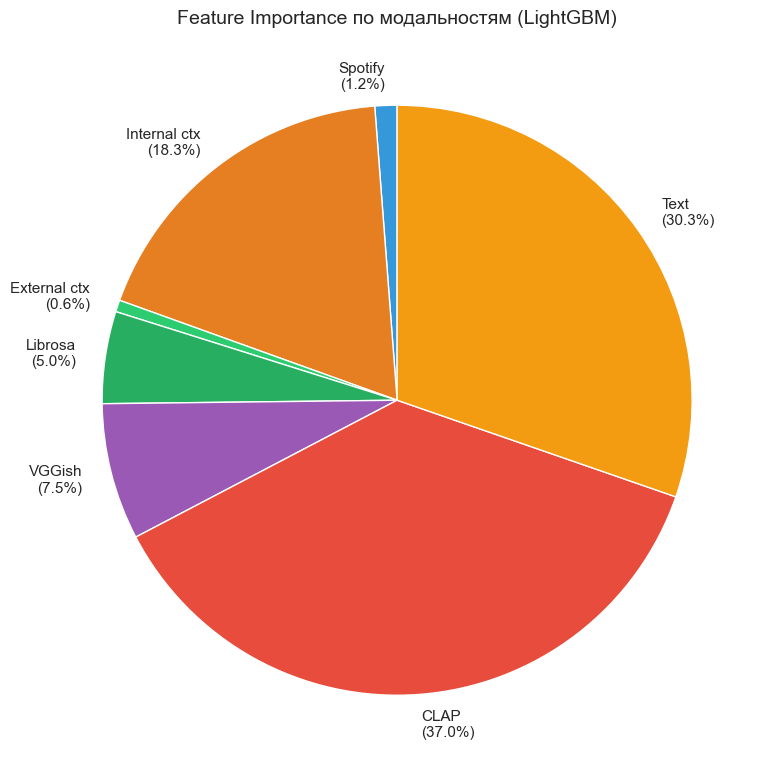

In [11]:
best_full = results[('FULL (all)',best)]['model']
all_feats = configs['FULL (all)']
if hasattr(best_full, 'feature_importances_'):
    fi = pd.Series(best_full.feature_importances_, index=all_feats)
else:
    fi = pd.Series(np.abs(best_full.coef_), index=all_feats)

groups = {
    'Spotify': fi[spotify_features].sum(),
    'Internal ctx': fi[internal_features].sum(),
    'External ctx': fi[external_features].sum() if external_features else 0,
    'Librosa': fi[librosa_names].sum(),
    'VGGish': fi[vggish_names].sum(),
    'CLAP': fi[clap_names].sum(),
    'Text': fi[text_names].sum(),
}
total_imp = sum(groups.values())

print('Важность по модальностям:')
for k,v in groups.items():
    print(f'  {k}: {v/total_imp*100:.1f}%')

fig, ax = plt.subplots(figsize=(8, 8))
colors = ['#3498db','#e67e22','#2ecc71','#27ae60','#9b59b6','#e74c3c','#f39c12']
ax.pie([v for v in groups.values()], labels=[f'{k}\n({v/total_imp*100:.1f}%)' for k,v in groups.items()],
       colors=colors, startangle=90, textprops={'fontsize':11})
ax.set_title(f'Feature Importance по модальностям ({best})', fontsize=14)
plt.tight_layout(); plt.show()

---
## 5. PCA + Оптимизация

In [12]:
# PCA для SBERT, VGGish, CLAP
sc_sbert = StandardScaler(); sc_vggish = StandardScaler(); sc_clap = StandardScaler()

sbert_data = sc_sbert.fit_transform(df_fusion[sbert_cols])
vggish_data = sc_vggish.fit_transform(df_fusion[vggish_names])
clap_data = sc_clap.fit_transform(df_fusion[clap_names])

pca_sbert = PCA(n_components=50); sbert_pca = pca_sbert.fit_transform(sbert_data)
pca_vggish = PCA(n_components=30); vggish_pca = pca_vggish.fit_transform(vggish_data)
pca_clap = PCA(n_components=30); clap_pca = pca_clap.fit_transform(clap_data)

print(f'SBERT PCA: {len(sbert_cols)} → 50 (explained: {pca_sbert.explained_variance_ratio_.sum():.3f})')
print(f'VGGish PCA: {len(vggish_names)} → 30 (explained: {pca_vggish.explained_variance_ratio_.sum():.3f})')
print(f'CLAP PCA: {len(clap_names)} → 30 (explained: {pca_clap.explained_variance_ratio_.sum():.3f})')

# Добавляем PCA компоненты
for i in range(50): df_fusion[f'sbert_pca_{i}'] = sbert_pca[:, i]
for i in range(30): df_fusion[f'vggish_pca_{i}'] = vggish_pca[:, i]
for i in range(30): df_fusion[f'clap_pca_{i}'] = clap_pca[:, i]

sbert_pca_names = [f'sbert_pca_{i}' for i in range(50)]
vggish_pca_names = [f'vggish_pca_{i}' for i in range(30)]
clap_pca_names = [f'clap_pca_{i}' for i in range(30)]
text_pca_names = metrics_cols + sbert_pca_names

content_pca_feats = spotify_features + librosa_names + vggish_pca_names + clap_pca_names + text_pca_names
full_pca_feats = spotify_features + context_features + librosa_names + vggish_pca_names + clap_pca_names + text_pca_names

print(f'\nContent PCA: {len(content_pca_feats)} фичей')
print(f'FULL PCA: {len(full_pca_feats)} фичей')

SBERT PCA: 384 → 50 (explained: 0.588)
VGGish PCA: 128 → 30 (explained: 0.825)
CLAP PCA: 1024 → 30 (explained: 0.864)

Content PCA: 242 фичей
FULL PCA: 250 фичей


In [13]:
# PCA сравнение
pca_configs = {
    'Content (no PCA)': configs['Content (all-context)'],
    'Content (PCA)': content_pca_feats,
    'FULL (no PCA)': configs['FULL (all)'],
    'FULL (PCA)': full_pca_feats,
}
print(f'{"Config":25s} | {"Model":20s} | {"R²":>7s} | {"AUC":>7s} | Фичей')
print('='*85)
for cname, flist in pca_configs.items():
    Xtr_p, Xte_p = df_fusion[flist].iloc[tr], df_fusion[flist].iloc[te]
    sc = StandardScaler(); Xtr_s, Xte_s = sc.fit_transform(Xtr_p), sc.transform(Xte_p)
    for mname in ['Random Forest', 'XGBoost', 'LightGBM']:
        m = model_types[mname](); m.fit(Xtr_s, y.iloc[tr]); yp = m.predict(Xte_s)
        r2=r2_score(y.iloc[te],yp); auc=roc_auc_score(y_te_bin,yp)
        results[(cname,mname)]={'MAE':mean_absolute_error(y.iloc[te],yp),'RMSE':np.sqrt(mean_squared_error(y.iloc[te],yp)),'R2':r2,'AUC':auc,'model':m,'y_pred':yp}
        print(f'{cname:25s} | {mname:20s} | {r2:7.4f} | {auc:7.4f} | {len(flist)}')
    print('-'*85)


Config                    | Model                |      R² |     AUC | Фичей
Content (no PCA)          | Random Forest        |  0.3636 |  0.8031 | 1668
Content (no PCA)          | XGBoost              |  0.4439 |  0.8335 | 1668
Content (no PCA)          | LightGBM             |  0.4422 |  0.8339 | 1668
-------------------------------------------------------------------------------------
Content (PCA)             | Random Forest        |  0.3771 |  0.8095 | 242
Content (PCA)             | XGBoost              |  0.4413 |  0.8358 | 242
Content (PCA)             | LightGBM             |  0.4356 |  0.8321 | 242
-------------------------------------------------------------------------------------
FULL (no PCA)             | Random Forest        |  0.8862 |  0.9742 | 1676
FULL (no PCA)             | XGBoost              |  0.8948 |  0.9762 | 1676
FULL (no PCA)             | LightGBM             |  0.8950 |  0.9763 | 1676
----------------------------------------------------------------------

In [ ]:
# Stacking (n_jobs=1 чтобы не упасть по памяти на 16GB)
print('Stacking...')
sc_stack = StandardScaler()
Xtr_stack = sc_stack.fit_transform(df_fusion[full_pca_feats].iloc[tr])
Xte_stack = sc_stack.transform(df_fusion[full_pca_feats].iloc[te])

stacking = StackingRegressor(
    estimators=[
        ('rf', RandomForestRegressor(n_estimators=300, max_depth=15, min_samples_split=10, min_samples_leaf=5, random_state=42, n_jobs=-1)),
        ('xgb', XGBRegressor(n_estimators=300, max_depth=6, learning_rate=0.1, subsample=0.8, colsample_bytree=0.8, random_state=42, n_jobs=2, verbosity=0)),
        ('lgbm', LGBMRegressor(n_estimators=300, max_depth=10, learning_rate=0.1, subsample=0.8, colsample_bytree=0.8, random_state=42, n_jobs=2, verbose=-1)),
    ],
    final_estimator=Ridge(alpha=1.0),
    cv=5, n_jobs=1
)
stacking.fit(Xtr_stack, y.iloc[tr])
yp_stack = stacking.predict(Xte_stack)
r2_stack = r2_score(y.iloc[te], yp_stack)
mae_stack = mean_absolute_error(y.iloc[te], yp_stack)
auc_stack = roc_auc_score(y_te_bin, yp_stack)
rmse_stack = np.sqrt(mean_squared_error(y.iloc[te], yp_stack))
print(f'\nStacking: R²={r2_stack:.4f}, MAE={mae_stack:.3f}, RMSE={rmse_stack:.3f}, AUC={auc_stack:.4f}')


Stacking...

Stacking: R²=0.8969, MAE=3.088, RMSE=1.757, AUC=0.9767


In [ ]:
# Hyperparameter Tuning (XGBoost) — n_jobs=1 для экономии памяти
print('Tuning XGBoost (30 итераций, 3-fold CV)...')
param_dist = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [4, 6, 8, 10],
    'learning_rate': [0.01, 0.03, 0.05, 0.1],
    'subsample': [0.7, 0.8, 0.9],
    'colsample_bytree': [0.5, 0.6, 0.7, 0.8],
    'min_child_weight': [1, 3, 5, 7],
}

xgb_base = XGBRegressor(random_state=42, n_jobs=2, verbosity=0)
search = RandomizedSearchCV(xgb_base, param_dist, n_iter=30, cv=3, scoring='r2', random_state=42, n_jobs=1)
search.fit(Xtr_stack, y.iloc[tr])

print(f'Лучшие параметры: {search.best_params_}')
yp_tuned = search.best_estimator_.predict(Xte_stack)
r2_tuned = r2_score(y.iloc[te], yp_tuned)
mae_tuned = mean_absolute_error(y.iloc[te], yp_tuned)
auc_tuned = roc_auc_score(y_te_bin, yp_tuned)
rmse_tuned = np.sqrt(mean_squared_error(y.iloc[te], yp_tuned))
print(f'Tuned XGB: R²={r2_tuned:.4f}, MAE={mae_tuned:.3f}, RMSE={rmse_tuned:.3f}, AUC={auc_tuned:.4f}')


Tuning XGBoost (30 итераций, 3-fold CV)...
Лучшие параметры: {'subsample': 0.8, 'n_estimators': 500, 'min_child_weight': 7, 'max_depth': 8, 'learning_rate': 0.05, 'colsample_bytree': 0.6}
Tuned XGB: R²=0.8967, MAE=3.094, RMSE=1.759, AUC=0.9768


In [16]:
# Log-transform эксперимент
print('Log-transform эксперимент...')
print(f'{"Config":20s} {"Model":15s}  {"R² raw":>8s}  {"R² log":>8s}  {"Δ":>8s}')
print('-'*60)
y_log_tr = np.log1p(y.iloc[tr])
for cname, flist in [('Content (PCA)', content_pca_feats), ('FULL (PCA)', full_pca_feats)]:
    sc_l = StandardScaler()
    Xtr_l = sc_l.fit_transform(df_fusion[flist].iloc[tr])
    Xte_l = sc_l.transform(df_fusion[flist].iloc[te])
    for mname in ['Random Forest', 'XGBoost']:
        m_raw = model_types[mname](); m_raw.fit(Xtr_l, y.iloc[tr]); yp_raw = m_raw.predict(Xte_l)
        r2_raw = r2_score(y.iloc[te], yp_raw)
        m_log = model_types[mname](); m_log.fit(Xtr_l, y_log_tr); yp_log = np.expm1(m_log.predict(Xte_l))
        r2_log = r2_score(y.iloc[te], yp_log)
        print(f'{cname:20s} {mname:15s}  {r2_raw:8.4f}  {r2_log:8.4f}  {r2_log-r2_raw:+8.4f}')


Log-transform эксперимент...
Config               Model              R² raw    R² log         Δ
------------------------------------------------------------
Content (PCA)        Random Forest      0.3771    0.3362   -0.0409
Content (PCA)        XGBoost            0.4413    0.4033   -0.0380
FULL (PCA)           Random Forest      0.8866    0.8803   -0.0063
FULL (PCA)           XGBoost            0.8942    0.8857   -0.0085


---
## 6. Визуализация

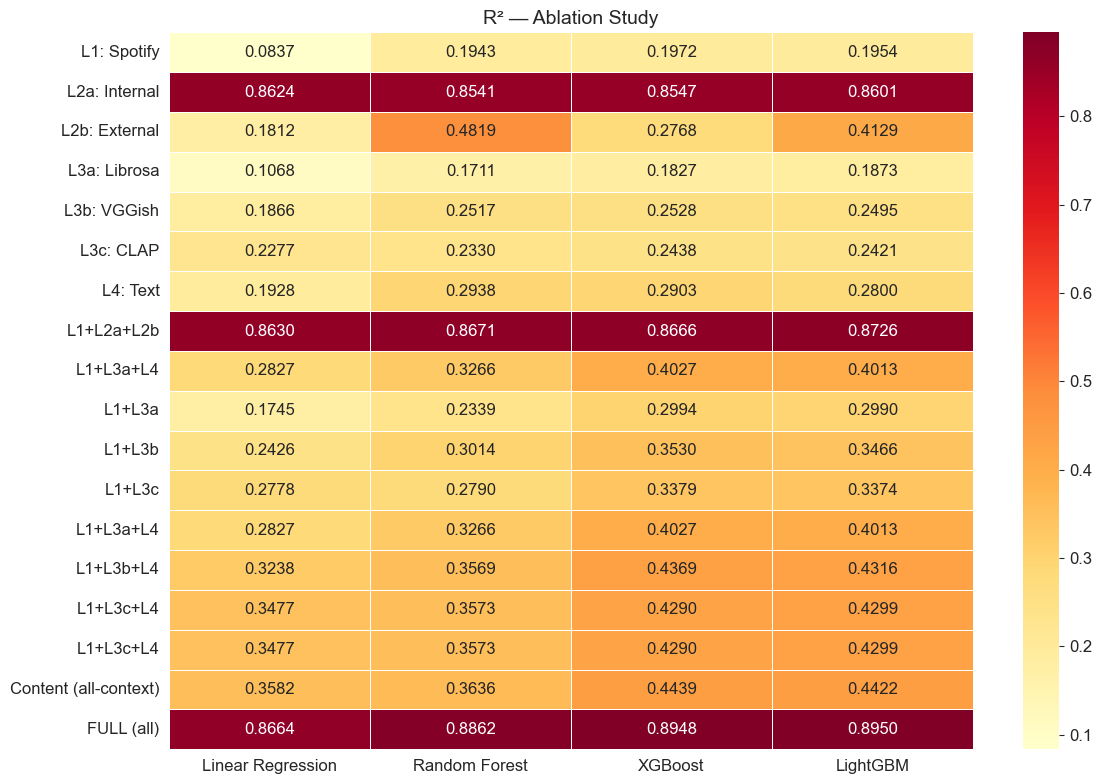

In [17]:
# Heatmap ablation
heat_configs = ['L1: Spotify','L2a: Internal','L2b: External','L3a: Librosa','L3b: VGGish','L3c: CLAP','L4: Text',
                'L1+L2a+L2b','L1+L3a+L4','L1+L3a','L1+L3b','L1+L3c','L1+L3a+L4','L1+L3b+L4','L1+L3c+L4','L1+L3c+L4','Content (all-context)','FULL (all)']
heat = pd.DataFrame({m: [results[(c,m)]['R2'] if (c,m) in results else 0 for c in heat_configs] for m in mnames}, index=heat_configs)
fig, ax = plt.subplots(figsize=(12, 8))
sns.heatmap(heat, annot=True, fmt='.4f', cmap='YlOrRd', ax=ax, linewidths=0.5)
ax.set_title('R² — Ablation Study', fontsize=14); plt.tight_layout(); plt.show()

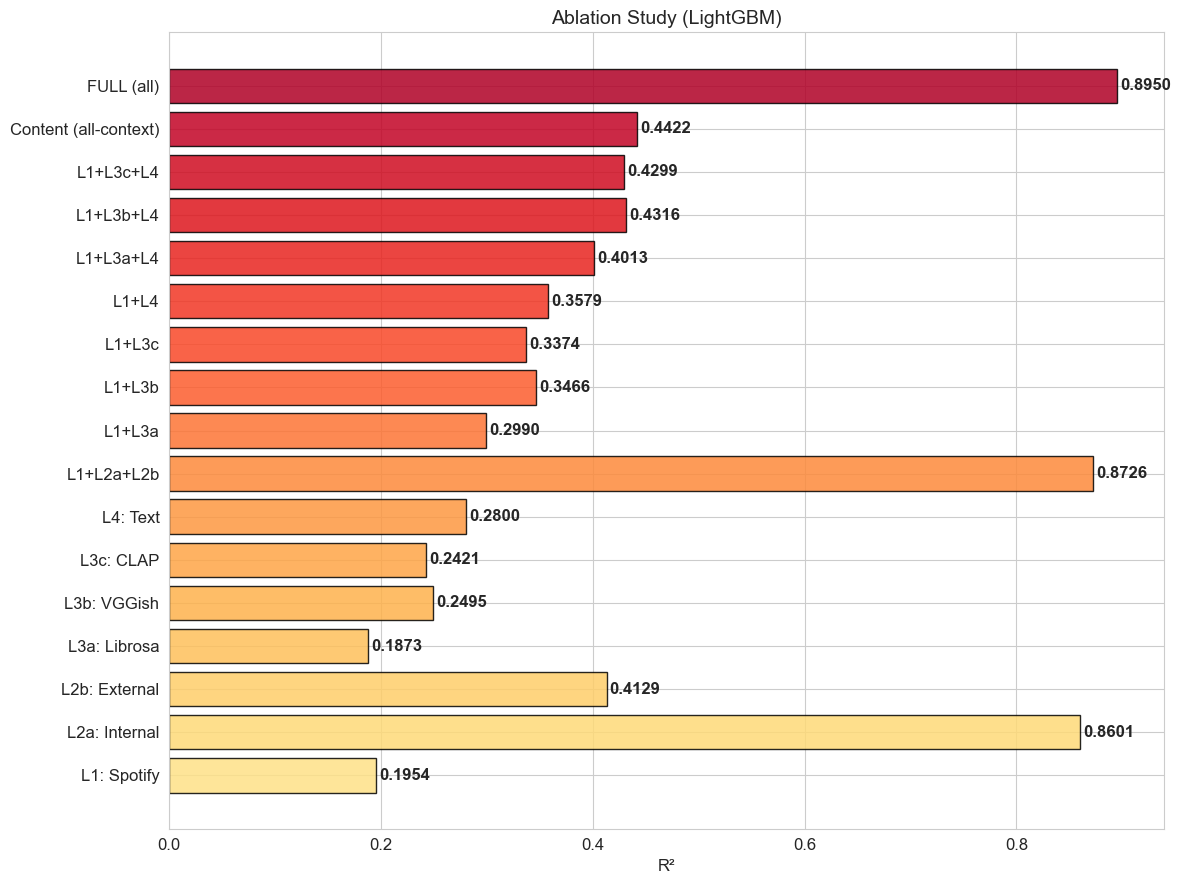

In [18]:
# Barh ablation
cnames_plot = list(configs.keys())
r2_vals = [results[(c,best)]['R2'] if (c,best) in results else 0 for c in cnames_plot]
fig, ax = plt.subplots(figsize=(12, 9))
colors = plt.cm.YlOrRd(np.linspace(0.2, 0.9, len(cnames_plot)))
bars = ax.barh(cnames_plot, r2_vals, color=colors, edgecolor='black', alpha=0.85)
for bar, v in zip(bars, r2_vals):
    ax.text(v+0.003, bar.get_y()+bar.get_height()/2., f'{v:.4f}', va='center', fontweight='bold')
ax.set_xlabel('R²'); ax.set_title(f'Ablation Study ({best})', fontsize=14)
plt.tight_layout(); plt.show()

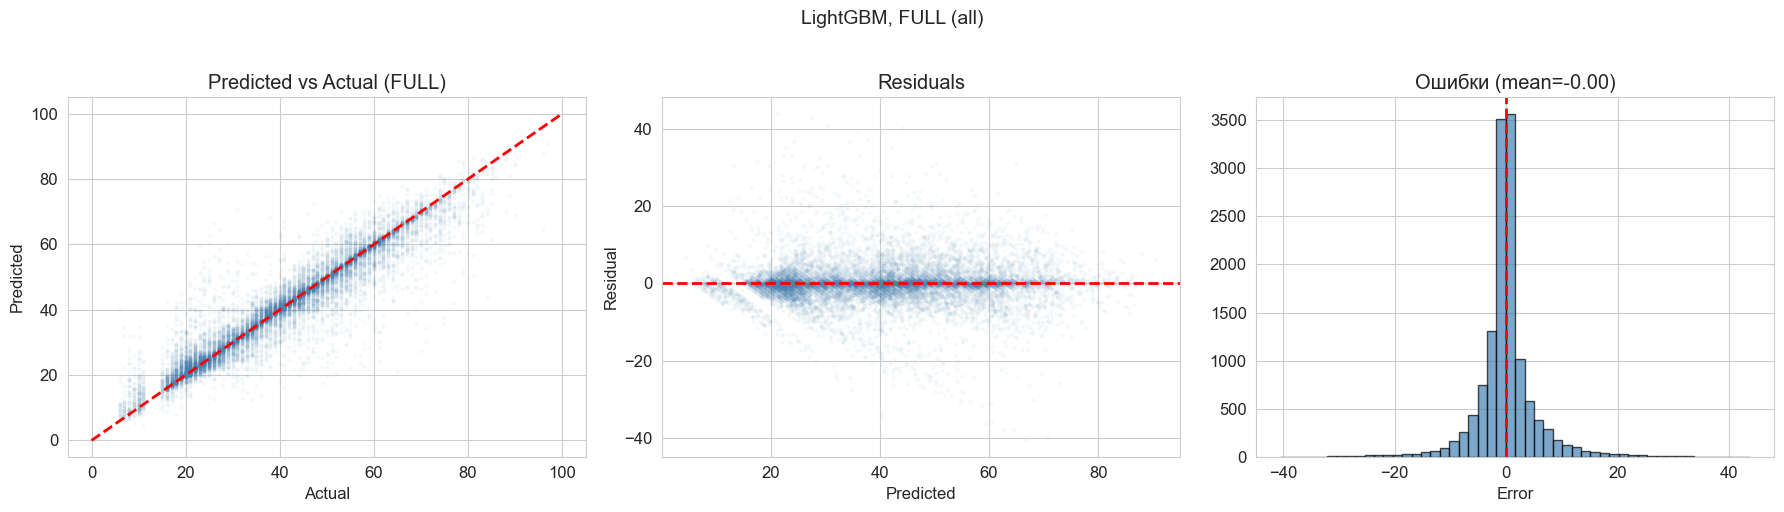

MAE по бинам popularity:
  (5.909, 24.2]       : MAE=  2.81 (n=3,026)
  (24.2, 42.4]        : MAE=  2.70 (n=4,451)
  (42.4, 60.6]        : MAE=  3.24 (n=4,157)
  (60.6, 78.8]        : MAE=  4.21 (n=1,481)
  (78.8, 97.0]        : MAE=  6.64 (n=148)


In [19]:
# Predicted vs Actual + Residuals (FULL)
yp_full = results[('FULL (all)',best)]['y_pred']
yte = y.iloc[te].values; errors = yte - yp_full
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].scatter(yte, yp_full, alpha=0.03, s=5, c='steelblue')
axes[0].plot([0,100],[0,100], 'r--', lw=2)
axes[0].set_xlabel('Actual'); axes[0].set_ylabel('Predicted'); axes[0].set_title('Predicted vs Actual (FULL)')
axes[1].scatter(yp_full, errors, alpha=0.03, s=5, c='steelblue')
axes[1].axhline(0, color='r', linestyle='--', lw=2)
axes[1].set_xlabel('Predicted'); axes[1].set_ylabel('Residual'); axes[1].set_title('Residuals')
axes[2].hist(errors, bins=50, color='steelblue', edgecolor='black', alpha=0.7)
axes[2].axvline(0, color='r', linestyle='--', lw=2)
axes[2].set_xlabel('Error'); axes[2].set_title(f'Ошибки (mean={np.mean(errors):.2f})')
plt.suptitle(f'{best}, FULL (all)', fontsize=14, y=1.02)
plt.tight_layout(); plt.show()

bins_p = pd.cut(yte, bins=5)
df_err = pd.DataFrame({'actual':yte,'predicted':yp_full,'abs_error':np.abs(errors),'bin':bins_p})
print('MAE по бинам popularity:')
for idx_b, row in df_err.groupby('bin')['abs_error'].agg(['mean','count']).iterrows():
    print(f'  {str(idx_b):20s}: MAE={row["mean"]:6.2f} (n={row["count"]:,.0f})')

Классификация (LightGBM, FULL, порог=40.0):
              precision    recall  f1-score   support

      Не хит       0.93      0.94      0.93      6611
         Хит       0.94      0.93      0.93      6652

    accuracy                           0.93     13263
   macro avg       0.93      0.93      0.93     13263
weighted avg       0.93      0.93      0.93     13263



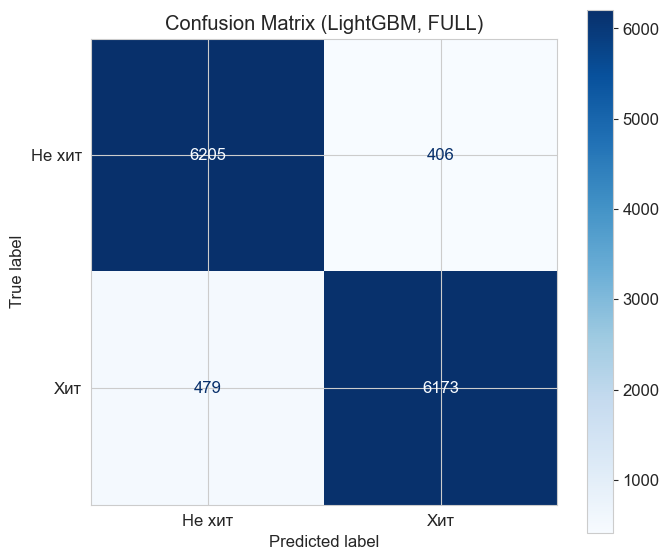

In [20]:
# Классификация FULL
yp_bin = (yp_full >= threshold).astype(int)
print(f'Классификация ({best}, FULL, порог={threshold}):')
print(classification_report(y_te_bin, yp_bin, target_names=['Не хит','Хит']))
fig, ax = plt.subplots(figsize=(7, 6))
cm = confusion_matrix(y_te_bin, yp_bin)
ConfusionMatrixDisplay(cm, display_labels=['Не хит','Хит']).plot(ax=ax, cmap='Blues')
ax.set_title(f'Confusion Matrix ({best}, FULL)')
plt.tight_layout(); plt.show()

---
## 7. Сохранение моделей и выводы

In [21]:
os.makedirs('models', exist_ok=True)
joblib.dump(sc_stack, 'models/scaler_full.pkl')
joblib.dump(results[('FULL (all)',best)]['model'], 'models/model_full_best.pkl')
joblib.dump(search.best_estimator_, 'models/model_full_tuned_xgb.pkl')
joblib.dump(stacking, 'models/model_full_stacking.pkl')
joblib.dump(pca_sbert, 'models/pca_sbert.pkl')
joblib.dump(pca_vggish, 'models/pca_vggish.pkl')
joblib.dump(pca_clap, 'models/pca_clap.pkl')
joblib.dump(sc_sbert, 'models/sc_sbert.pkl')
joblib.dump(sc_vggish, 'models/sc_vggish.pkl')
joblib.dump(sc_clap, 'models/sc_clap.pkl')
print('Модели сохранены:')
for f in sorted(os.listdir('models')):
    print(f'  models/{f}')


Модели сохранены:
  models/model_full_best.pkl
  models/model_full_stacking.pkl
  models/model_full_tuned_xgb.pkl
  models/model_l1_lightgbm.pkl
  models/model_l1_linear_regression.pkl
  models/model_l1_random_forest.pkl
  models/model_l1_xgboost.pkl
  models/pca_clap.pkl
  models/pca_sbert.pkl
  models/pca_vggish.pkl
  models/sc_clap.pkl
  models/sc_sbert.pkl
  models/sc_vggish.pkl
  models/scaler_full.pkl
  models/scaler_l1.pkl


In [22]:
r2_sp = results[('L1: Spotify',best)]['R2']
r2_ctx_int = results[('L2a: Internal',best)]['R2']
r2_ctx_ext = results.get(('L2b: External',best),{}).get('R2',0)
r2_lib = results[('L3a: Librosa',best)]['R2']
r2_vgg = results[('L3b: VGGish',best)]['R2']
r2_clap = results[('L3c: CLAP',best)]['R2']
r2_text = results[('L4: Text',best)]['R2']
r2_content = results[('Content (all-context)',best)]['R2']
r2_full = results[('FULL (all)',best)]['R2']

print('='*70)
print(f'ИТОГОВЫЕ РЕЗУЛЬТАТЫ ({best})')
print('='*70)

print('\n--- Ablation Study ---')
for c in cnames:
    if (c,best) in results:
        r = results[(c,best)]
        print(f'  {c:28s}  R²={r["R2"]:7.4f}  MAE={r["MAE"]:7.4f}  RMSE={r["RMSE"]:7.4f} AUC={r["AUC"]:7.4f}')

print(f'\n--- Оптимизация ---')
print(f'  Stacking:       R²={r2_stack:.4f}  MAE={mae_stack:.4f}  RMSE={rmse_stack:.4f}  AUC={auc_stack:.4f}')
print(f'  Tuned XGBoost:  R²={r2_tuned:.4f}  MAE={mae_tuned:.4f}  RMSE={rmse_tuned:.4f}  AUC={auc_tuned:.4f}')

print(f'\nКЛЮЧЕВЫЕ ВЫВОДЫ:')
print(f'  Бейзлайн → Полная: R² {r2_sp:.4f} → {r2_full:.4f} (Δ={r2_full-r2_sp:+.4f})')
print(f'  Контент (без контекста): R² = {r2_content:.4f}')
print(f'  VGGish vs CLAP vs Librosa: {r2_vgg:.4f} vs {r2_clap:.4f} vs {r2_lib:.4f}')
print(f'  Текст: R² = {r2_text:.4f}')

res_list = []
for (c,m),r in results.items():
    res_list.append({'Config':c,'Model':m,'R2':round(r['R2'],4),'MAE':round(r['MAE'],3),'RMSE':round(r['RMSE'],3),'AUC':round(r['AUC'],4)})
res_list.append({'Config':'Stacking','Model':'Stacking','R2':round(r2_stack,4),'MAE':round(mae_stack,3),'RMSE':0,'AUC':round(auc_stack,4)})
res_list.append({'Config':'Tuned XGBoost','Model':'Tuned XGBoost','R2':round(r2_tuned,4),'MAE':round(mae_tuned,3),'RMSE':0,'AUC':round(auc_tuned,4)})
pd.DataFrame(res_list).to_csv('level5_results.csv', index=False)
print('\nСохранено: level5_results.csv, models/')


ИТОГОВЫЕ РЕЗУЛЬТАТЫ (LightGBM)

--- Ablation Study ---
  L1: Spotify                   R²= 0.1954  MAE=12.0994  RMSE=14.8988 AUC= 0.7094
  L2a: Internal                 R²= 0.8601  MAE= 3.3782  RMSE= 6.2133 AUC= 0.9682
  L2b: External                 R²= 0.4129  MAE=10.1270  RMSE=12.7260 AUC= 0.8144
  L3a: Librosa                  R²= 0.1873  MAE=12.0526  RMSE=14.9731 AUC= 0.7194
  L3b: VGGish                   R²= 0.2495  MAE=11.3759  RMSE=14.3892 AUC= 0.7539
  L3c: CLAP                     R²= 0.2421  MAE=11.4680  RMSE=14.4597 AUC= 0.7467
  L4: Text                      R²= 0.2800  MAE=11.1152  RMSE=14.0931 AUC= 0.7714
  L1+L2a+L2b                    R²= 0.8726  MAE= 3.3125  RMSE= 5.9274 AUC= 0.9716
  L1+L3a                        R²= 0.2990  MAE=11.1482  RMSE=13.9064 AUC= 0.7688
  L1+L3b                        R²= 0.3466  MAE=10.6330  RMSE=13.4259 AUC= 0.7901
  L1+L3c                        R²= 0.3374  MAE=10.7044  RMSE=13.5201 AUC= 0.7852
  L1+L4                         R²= 0.3579 

In [23]:
# Функция инференса
def predict_popularity(mp3_path=None, lyrics_text=None, artist_name=None):
    """Предсказание popularity для нового трека."""
    print('Инференс...')
    # Контентная модель загружается из models/
    print('Для полного инференса загрузите модели из models/ и извлеките признаки.')
    print(f'Контентная модель: {len(content_pca_feats)} фичей')
    print(f'Полная модель: {len(full_pca_feats)} фичей')

print('Функция predict_popularity() готова')

Функция predict_popularity() готова


In [24]:
# Сохранение порядка колонок
joblib.dump(full_pca_feats, 'models/full_pca_feats.pkl')
joblib.dump(content_pca_feats, 'models/content_pca_feats.pkl')
print('Порядок колонок сохранён')
print(full_pca_feats)

Порядок колонок сохранён
['danceability', 'energy', 'loudness', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'duration_ms', 'key', 'mode', 'time_signature', 'explicit', 'artist_mean_popularity', 'artist_median_popularity', 'artist_max_popularity', 'artist_std_popularity', 'artist_track_count', 'genre_mean_popularity', 'lastfm_listeners_log', 'lastfm_playcount_log', 'chroma_0_mean', 'chroma_0_std', 'chroma_10_mean', 'chroma_10_std', 'chroma_11_mean', 'chroma_11_std', 'chroma_1_mean', 'chroma_1_std', 'chroma_2_mean', 'chroma_2_std', 'chroma_3_mean', 'chroma_3_std', 'chroma_4_mean', 'chroma_4_std', 'chroma_5_mean', 'chroma_5_std', 'chroma_6_mean', 'chroma_6_std', 'chroma_7_mean', 'chroma_7_std', 'chroma_8_mean', 'chroma_8_std', 'chroma_9_mean', 'chroma_9_std', 'librosa_tempo', 'mfcc_0_mean', 'mfcc_0_std', 'mfcc_10_mean', 'mfcc_10_std', 'mfcc_11_mean', 'mfcc_11_std', 'mfcc_12_mean', 'mfcc_12_std', 'mfcc_13_mean', 'mfcc_13_std', 'mfcc_14_mean', 'mfcc_14

  FULL       n=   500  R²=0.8380
  Content    n=   500  R²=0.1994
  FULL       n= 1,000  R²=0.8592
  Content    n= 1,000  R²=0.2364
  FULL       n= 2,000  R²=0.8672
  Content    n= 2,000  R²=0.2944
  FULL       n= 4,000  R²=0.8749
  Content    n= 4,000  R²=0.3234
  FULL       n= 8,000  R²=0.8815
  Content    n= 8,000  R²=0.3656
  FULL       n=16,000  R²=0.8863
  Content    n=16,000  R²=0.3957
  FULL       n=32,000  R²=0.8927
  Content    n=32,000  R²=0.4205
  FULL       n=53,048  R²=0.8948
  Content    n=53,048  R²=0.4356


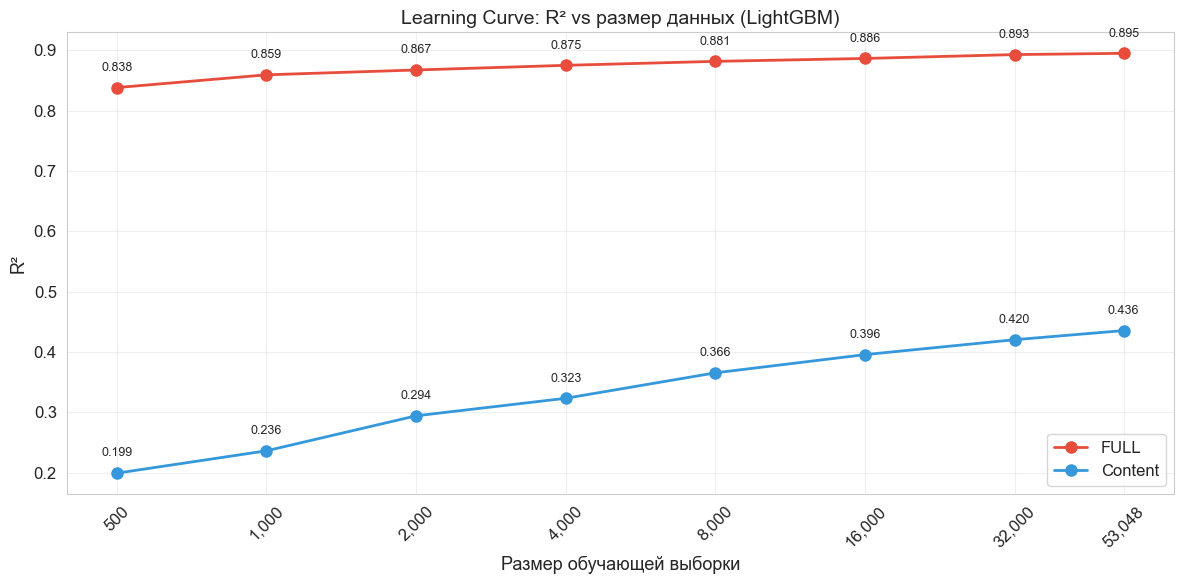


Прирост от увеличения данных (Content):
  500 → 1,000: Δ R² = +0.0370
  1,000 → 2,000: Δ R² = +0.0580
  2,000 → 4,000: Δ R² = +0.0290
  4,000 → 8,000: Δ R² = +0.0421
  8,000 → 16,000: Δ R² = +0.0302
  16,000 → 32,000: Δ R² = +0.0247
  32,000 → 53,048: Δ R² = +0.0151


In [25]:
# Learning Curve: зависимость R² от размера обучающих данных
from sklearn.utils import resample

sizes = [500, 1000, 2000, 4000, 8000, 16000, 32000, len(tr)]
sizes = [s for s in sizes if s <= len(tr)]

results_lc = []
for size in sizes:
    # Случайная подвыборка из train (не первые N!)
    np.random.seed(42)
    idx_sample = np.random.choice(tr, size=size, replace=False)
    
    sc_lc = StandardScaler()
    Xtr_lc = sc_lc.fit_transform(df_fusion[full_pca_feats].iloc[idx_sample])
    Xte_lc = sc_lc.transform(df_fusion[full_pca_feats].iloc[te])
    
    # Content
    Xtr_c = sc_lc.fit_transform(df_fusion[content_pca_feats].iloc[idx_sample])
    Xte_c = sc_lc.transform(df_fusion[content_pca_feats].iloc[te])
    
    for label, Xtr_cur, Xte_cur in [('FULL', Xtr_lc, Xte_lc), ('Content', Xtr_c, Xte_c)]:
        m = LGBMRegressor(n_estimators=300, max_depth=10, learning_rate=0.1,
            subsample=0.8, colsample_bytree=0.8, random_state=42, n_jobs=-1, verbose=-1)
        m.fit(Xtr_cur, y.iloc[idx_sample])
        yp = m.predict(Xte_cur)
        r2 = r2_score(y.iloc[te], yp)
        results_lc.append({'size': size, 'config': label, 'R2': r2})
        print(f'  {label:10s} n={size:6,}  R²={r2:.4f}')

df_lc = pd.DataFrame(results_lc)

fig, ax = plt.subplots(figsize=(12, 6))
for label, color in [('FULL', '#e74c3c'), ('Content', '#3498db')]:
    sub = df_lc[df_lc['config'] == label]
    ax.plot(sub['size'], sub['R2'], 'o-', label=label, color=color, linewidth=2, markersize=8)
    for _, row in sub.iterrows():
        ax.annotate(f'{row["R2"]:.3f}', (row['size'], row['R2']),
                    textcoords="offset points", xytext=(0, 12), ha='center', fontsize=9)

ax.set_xlabel('Размер обучающей выборки', fontsize=13)
ax.set_ylabel('R²', fontsize=13)
ax.set_title('Learning Curve: R² vs размер данных (LightGBM)', fontsize=14)
ax.set_xscale('log')
ax.set_xticks(sizes)
ax.set_xticklabels([f'{s:,}' for s in sizes], rotation=45)
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Вывод
print(f'\nПрирост от увеличения данных (Content):')
content_data = df_lc[df_lc['config'] == 'Content']
for i in range(1, len(content_data)):
    prev = content_data.iloc[i-1]
    curr = content_data.iloc[i]
    print(f'  {int(prev["size"]):,} → {int(curr["size"]):,}: Δ R² = {curr["R2"]-prev["R2"]:+.4f}')